# Model building and evaluation

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("./data/processed/diabetes_food_clean.csv")

In [3]:
df.head()

,CountyID,FoodAccessScore,Urban,SeniorsRate,GroupQuarters,PovertyRatePerc,BlackRate,AsianRate,NHOPIRate,AIANRate,HispanicRate,DiabetesRate,Pop2010,State,County
0,1001,1.410529,0.534460,0.119954,0.008341,0.151376,0.176706,0.008686,0.000586,0.004251,0.024005,0.115555,54571,Alabama,Autauga County
1,1003,0.947357,0.453976,0.167712,0.012653,0.109479,0.093847,0.007396,0.000488,0.006672,0.043848,0.110982,182265,Alabama,Baldwin County
2,1005,1.328587,0.241760,0.142368,0.116296,0.293545,0.468915,0.003897,0.001056,0.004152,0.050515,0.177066,27457,Alabama,Barbour County
3,1007,0.000000,0.000000,0.126816,0.097054,0.138335,0.220249,0.000960,0.000567,0.002793,0.017718,0.131044,22915,Alabama,Bibb County
4,1009,0.245979,0.122989,0.147221,0.008522,0.146238,0.013276,0.002041,0.000663,0.005356,0.080702,0.123109,57322,Alabama,Blount County


In [4]:
# X and y after feature selection (county-level, population-weighted)
X = df[['FoodAccessScore', 'Urban', 'SeniorsRate', 'GroupQuarters', 'PovertyRatePerc',
        'BlackRate', 'AsianRate', 'NHOPIRate', 'AIANRate', 'HispanicRate', 'State']]
y = df['DiabetesRate']

# Linear Regression

In [5]:
# Encode state variable
preprocessor = ColumnTransformer(
    transformers=[
        ('state', OneHotEncoder(drop='first', handle_unknown='ignore'), ['State'])
    ],
    remainder='passthrough'
)
# Model pipeline
model = make_pipeline(
    preprocessor,
    LinearRegression()
)

# K-fold Validation
kf = KFold(n_splits = 5, shuffle = True, random_state = 22)
scores = cross_val_score(
    model,
    X,
    y,
    cv = kf,
    scoring ='r2'
)
print('Our K fold R^2 values are:', scores)
print('Our model R^2 on average is:', round(scores.mean(), 4))

Our K fold R^2 values are: [0.89607253 0.89100575 0.88870929 0.88969183 0.90588389]
Our model R^2 on average is: 0.8943


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


# Model interpretation

In [6]:
model = smf.ols(
    'DiabetesRate ~ State + FoodAccessScore + Urban + SeniorsRate + GroupQuarters + PovertyRatePerc +'
    'BlackRate + AsianRate + NHOPIRate + AIANRate + HispanicRate',
    data = df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           DiabetesRate   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     474.2
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:18:08   Log-Likelihood:                 10585.
No. Observations:                3121   AIC:                        -2.105e+04
Df Residuals:                    3061   BIC:                        -2.069e+04
Df Model:                          59                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

# XGBoost

In [7]:
# Encode state variable
preprocessor = ColumnTransformer(
    transformers=[
        ('state', OneHotEncoder(drop='first', handle_unknown='ignore'), ['State'])
    ],
    remainder='passthrough'
)
# Make model pipeline
model = make_pipeline(
    preprocessor,
    XGBRegressor(
        n_estimators = 100,
        learning_rate = 0.1,
        max_depth = 5,
        random_state = 22
        )
)
# K-fold validation
kf = KFold(n_splits = 5, shuffle = True, random_state = 22)
scores = cross_val_score(
    model,
    X,
    y,
    cv = kf,
    scoring ='r2'
)
print('Our K fold R^2 values are:', scores)
print('Our model R^2 on average is:', round(scores.mean(), 4))

Our K fold R^2 values are: [0.88476748 0.89658941 0.86150208 0.89101983 0.89591935]
Our model R^2 on average is: 0.886


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


# Random Forest

In [8]:
# Encode state variable
preprocessor = ColumnTransformer(
    transformers=[
        ('state', OneHotEncoder(drop='first', handle_unknown='ignore'), ['State'])
    ],
    remainder='passthrough'
)
# Make model pipeline
model = make_pipeline(
    preprocessor,
    RandomForestRegressor(
        n_jobs = -1, 
        random_state = 22
        )
)
# K-fold validation
kf = KFold(n_splits = 5, shuffle = True, random_state = 22)
scores = cross_val_score(
    model,
    X,
    y,
    cv = kf,
    scoring ='r2'
)
print('Our K fold R^2 values are:', scores)
print('Our model R^2 on average is:', round(scores.mean(), 4))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Our K fold R^2 values are: [0.83740744 0.853657   0.80447671 0.8518498  0.84506397]
Our model R^2 on average is: 0.8385


# Scaled Linear Regression

In [9]:
# Scale features
scaler = StandardScaler()
numeric_cols = df.select_dtypes(include='number').columns.drop('DiabetesRate')
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [10]:
# Fit model
model = smf.ols(
    'DiabetesRate ~ State + FoodAccessScore + Urban + SeniorsRate + GroupQuarters + PovertyRatePerc +'
    'BlackRate + AsianRate + NHOPIRate + AIANRate + HispanicRate',
    data = df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           DiabetesRate   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     474.2
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:18:10   Log-Likelihood:                 10585.
No. Observations:                3121   AIC:                        -2.105e+04
Df Residuals:                    3061   BIC:                        -2.069e+04
Df Model:                          59                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

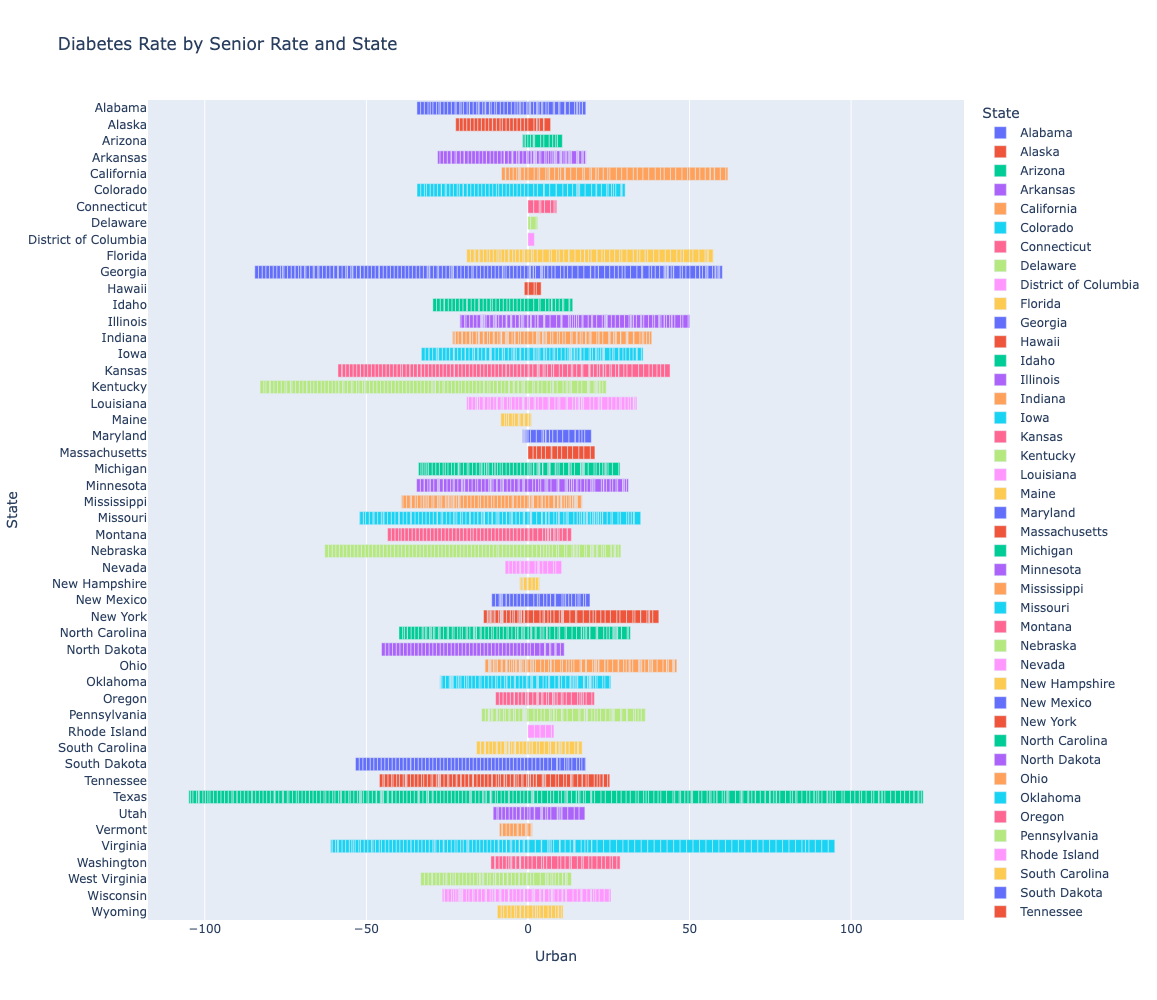

In [27]:
import plotly.express as px
fig = px.bar(
    df,
    x = 'Urban',
    y = 'State',
    color = 'State',
    title = "Diabetes Rate by Senior Rate and State",
)
fig.show()